In [1]:
suppressPackageStartupMessages({
    library(ggtree)
    library(phytools)
    library(ggvenn)
    require(igraph)
})

In [2]:
# load latest version of orthofinder results
OGs <- read.delim("/mnt/data01/yuanzhen/01.Vertebrate_cell_evo/02.gene_relationships/run5/results/Ortho_pipeline/OrthoFinder/Orthogroups/Orthogroups.tsv", header = T, sep = "\t")

In [3]:
species <- c("Bflo")

In [4]:
number_of_genes <- Reduce(rbind, lapply(species, FUN = function(s){
        paralogs <- Reduce(rbind, lapply(1:nrow(OGs), FUN = function(i){
            id_ <- stringr::str_split(OGs[i, s], ", ")[[1]]
            table <- data.frame(no = i, number = length(id_))
            return(table)
        }))
    paralogs$species <- s
    return(paralogs)
}))

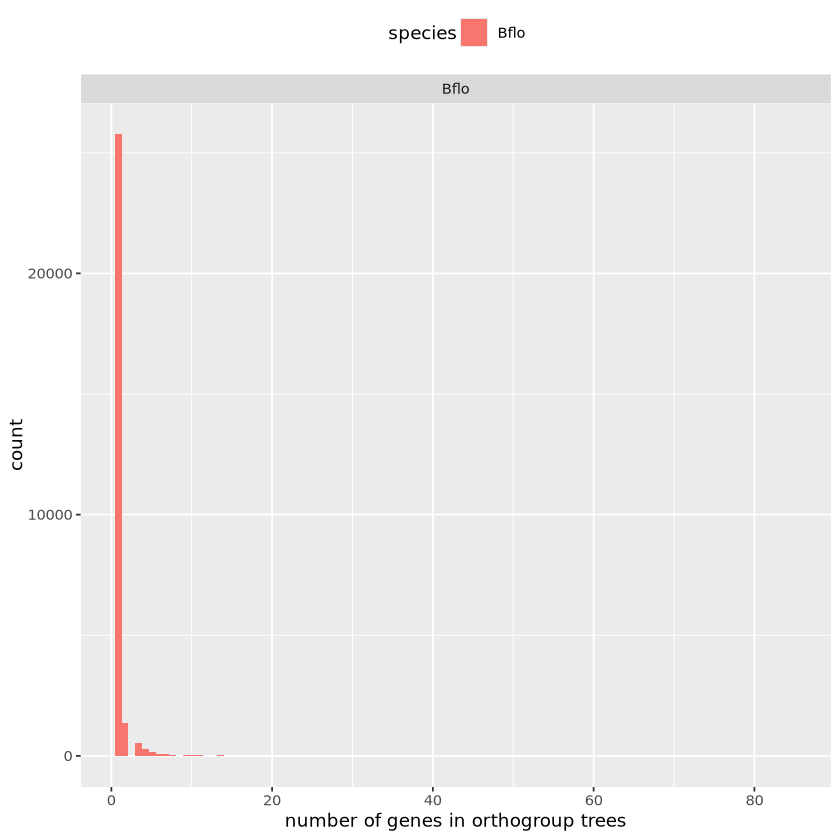

In [5]:
number_of_genes$species <- factor(number_of_genes$species, levels = species)
ggplot(number_of_genes, aes(x=number, fill = species)) +
    geom_histogram(bins = 100) + theme(legend.position="top") + facet_wrap(~ species, nrow = 6) + 
    xlab("number of genes in orthogroup trees")

In [6]:
results <- lapply(species, FUN = function(s){
    paralogs <- Reduce(rbind, lapply(1:nrow(OGs), FUN = function(i){
        id_ <- stringr::str_split(OGs[i, s], ", ")[[1]]
        if (length(id_) >=2 & length(id_) <= 30){
            # maybe ignore orthogroups contain too many copies (15) within single species?
            # only dozens of orthogroups will be filtered for each species if we do
            id_ <- combn(id_, 2)
            table <- data.frame(Dup1 = id_[1,], Dup2 = id_[2,])
            return(table)
        } else {
            return(NULL)
        }
    }))
    return(paralogs)
})
names(results) <- species

In [8]:
# store paralog results for each species
lapply(species, FUN = function(s){
    write.table(results[[s]], file = paste0(s, ".paralogs.latest.txt"), col.names = T, row.names = F, quote = F, sep = "\t")
})

[[1]]
NULL